In [20]:
#Implementació de Backpropagation y funciones de activación, en este notebook se implementara una red neuronal simple y se compararan las funciones de activación Sigmoid y reLU
#Importo librerías
import numpy as np
import matplotlib.pyplot as plt


In [21]:
#Creo funciones de activación
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return max(0, x)

In [31]:
#Creo el percepton
class Perceptron:

    def __init__(self, num_features, activation, learning_rate=0.1, epochs=20):
        self.weights = np.zeros(num_features + 1)
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.activation = activation

    def predict(self, x):

        z = np.dot(x, self.weights[1:]) + self.weights[0]

        output = self.activation(z)

        # Convertir salida a 0 o 1
        return 1 if output >= 0.5 else 0

In [34]:
#Entrenamiento
class Perceptron:

    def __init__(self, num_features, activation, learning_rate=0.1, epochs=20):
        self.weights = np.zeros(num_features + 1)
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.activation = activation

    def predict(self, x):
        z = np.dot(x, self.weights[1:]) + self.weights[0]
        output = self.activation(z)
        return 1 if output >= 0.5 else 0

    def train(self, X, y):

        errors = []

        for _ in range(self.epochs):

            total_error = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi)

                update = self.learning_rate * (target - prediction)

                self.weights[1:] += update * xi
                self.weights[0] += update

                total_error += abs(target - prediction)

            errors.append(total_error)

        return errors

In [24]:
#Creo dataset
X = np.array([
[0,0],
[0,1],
[1,0],
[1,1]
])

y = np.array([0,0,0,1])

In [35]:
#Entrenar con sigmoid
perceptron_sigmoid = Perceptron(num_features=2, activation=sigmoid)

errors_sigmoid = perceptron_sigmoid.train(X,y)

In [36]:
#Entrena con reLU
perceptron_relu = Perceptron(num_features=2, activation=relu)

errors_relu = perceptron_relu.train(X,y)

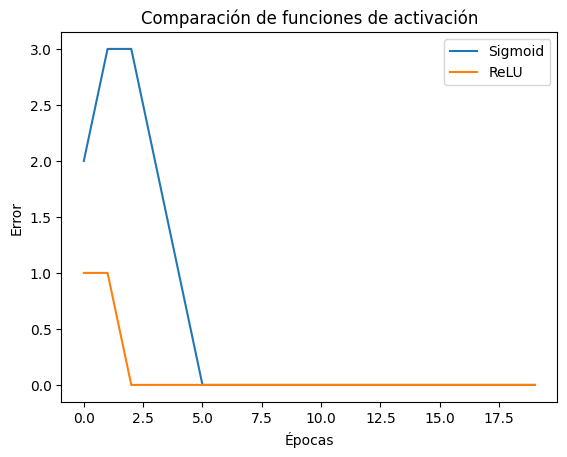

In [37]:
#Grafica de comparación
plt.plot(errors_sigmoid, label="Sigmoid")
plt.plot(errors_relu, label="ReLU")

plt.title("Comparación de funciones de activación")
plt.xlabel("Épocas")
plt.ylabel("Error")

plt.legend()
plt.show()

In [38]:
#Prueba
print("Resultados Sigmoid")

for xi in X:
    print(xi, perceptron_sigmoid.predict(xi))

print("Resultados ReLU")

for xi in X:
    print(xi, perceptron_relu.predict(xi))

Resultados Sigmoid
[0 0] 0
[0 1] 0
[1 0] 0
[1 1] 1
Resultados ReLU
[0 0] 0
[0 1] 0
[1 0] 0
[1 1] 1
